<a href="https://colab.research.google.com/github/gaga0321/scRNA-aging-analysis/blob/main/scRNA_aging_analysis_kidney.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install scanpy
import scanpy as sc
adata_aging = sc.read_h5ad("tabula-muris-senis-facs-processed-official-annotations-Kidney.h5ad")
print(list(adata_aging.obs.columns))

['FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden']


/usr/local/lib/python3.12/dist-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{
/usr/local/lib/python3.12/dist-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  return AnnData(**{


Ages in this cohort: ['18m', '24m', '3m']

Top 5 cell types found in this tissue:
cell_ontology_class
kidney collecting duct epithelial cell    445
epithelial cell of proximal tubule        393
fenestrated cell                          268
kidney collecting duct principal cell     157
macrophage                                152
Name: count, dtype: int64


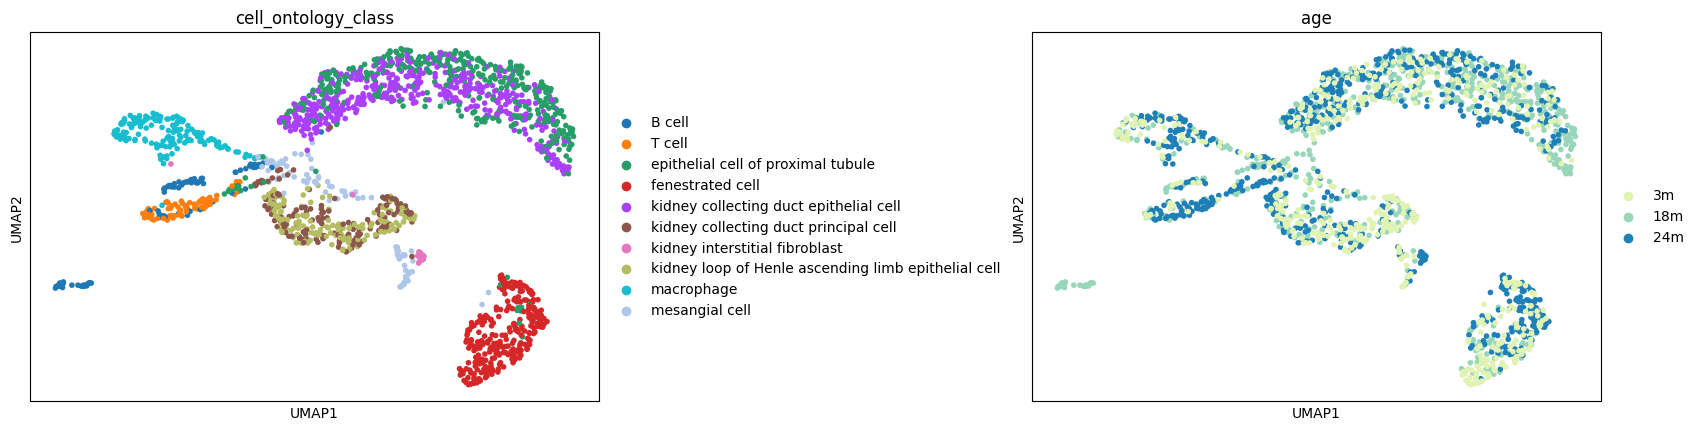

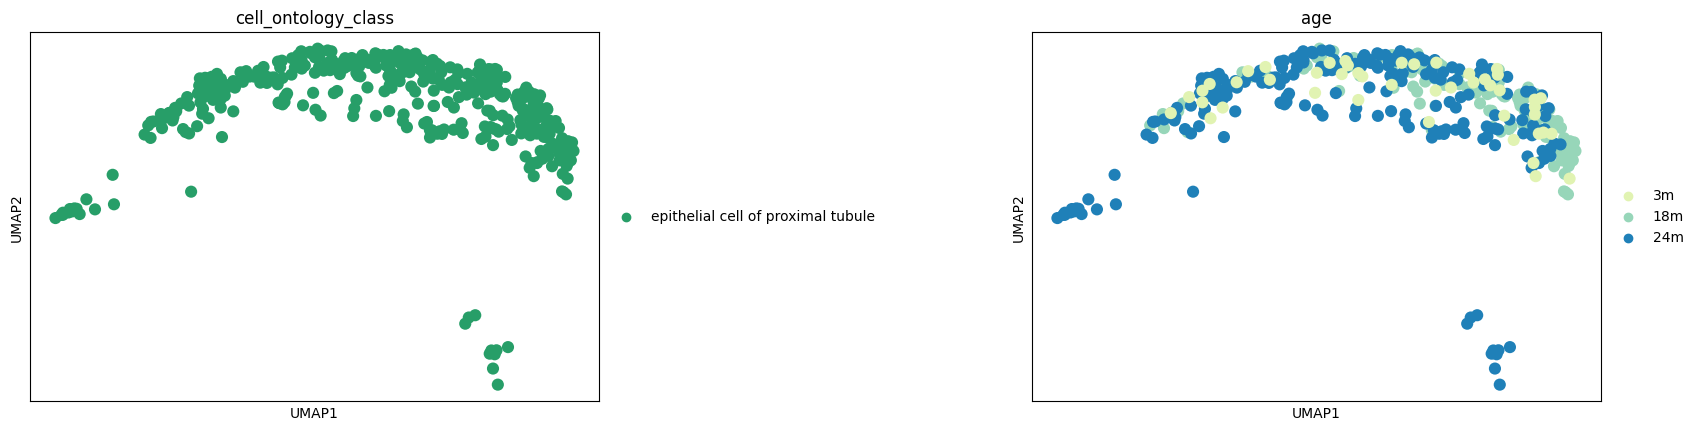

In [9]:
print("Ages in this cohort:", adata_aging.obs['age'].unique().tolist())
print("\nTop 5 cell types found in this tissue:")
print(adata_aging.obs['cell_ontology_class'].value_counts().head(5))
sc.pl.umap(adata_aging, color=['cell_ontology_class', 'age'], wspace=0.6)
proximal_tubule_cells = adata_aging[adata_aging.obs['cell_ontology_class'] == 'epithelial cell of proximal tubule'].copy()
sc.pl.umap(proximal_tubule_cells, color=['cell_ontology_class', 'age'], wspace=0.6)

Top 10 genes upregulated in 24-month old eplithelial cells:
    24m_n       24m_l     24m_p
0    Gpx3         NaN  0.000033
1   Rn45s         NaN  0.000071
2  Gm6981   36.339470  0.000071
3   Itm2b         inf  0.000169
4    Tpt1  616.419617  0.000205
5  Igfbp7         inf  0.000236
6  Cyp2a4         inf  0.000283
7  Eef1a1         NaN  0.000310
8    Ass1  444.419891  0.000310
9    Ly6e         inf  0.000467


/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (


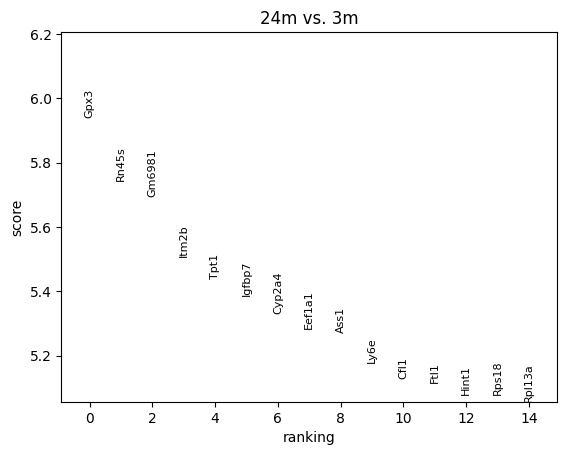

In [5]:
import pandas as pd
epithelial_cells = adata_aging[adata_aging.obs['cell_ontology_class'] == 'epithelial cell of proximal tubule'].copy()
sc.pp.normalize_total(epithelial_cells, target_sum=1e4)
sc.pp.log1p(epithelial_cells)
sc.tl.rank_genes_groups(
    epithelial_cells,
    groupby='age',
    groups=['24m'],
    reference='3m',
    method='wilcoxon'
)
result = epithelial_cells.uns['rank_genes_groups']
groups = result['names'].dtype.names
dataframe = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'logfoldchanges', 'pvals_adj']}
)
print("Top 10 genes upregulated in 24-month old eplithelial cells:")
print(dataframe[['24m_n', '24m_l', '24m_p']].head(10))
sc.pl.rank_genes_groups(epithelial_cells, groups=['24m'], n_genes=15, sharey=False)

In [6]:
!pip install gseapy
import gseapy as gp
import matplotlib.pyplot as plt
top_genes = dataframe['24m_n'].head(50).tolist()
print("Querying the Gene Ontology database...")
enr = gp.enrichr(
    gene_list=top_genes,
    gene_sets='GO_Biological_Process_2025',
    organism='mouse',
    outdir=None
)
results_df = enr.results
print("\nTop 5 Aging Pathways Disrupted:")
print(results_df[['Term', 'Adjusted P-value', 'Overlap']].head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 634.7/634.7 kB 11.1 MB/s eta 0:00:00
Querying the Gene Ontology database...

Top 5 Aging Pathways Disrupted:
                                              Term  Adjusted P-value Overlap
0             Cytoplasmic Translation (GO:0002181)      1.378330e-09   9/101
1  Macromolecule Biosynthetic Process (GO:0009059)      7.280403e-09  10/189
2                         Translation (GO:0006412)      3.646748e-08  10/232
3                     Gene Expression (GO:0010467)      3.207677e-06  10/381
4           Protein Metabolic Process (GO:0019538)      2.311439e-05  11/614


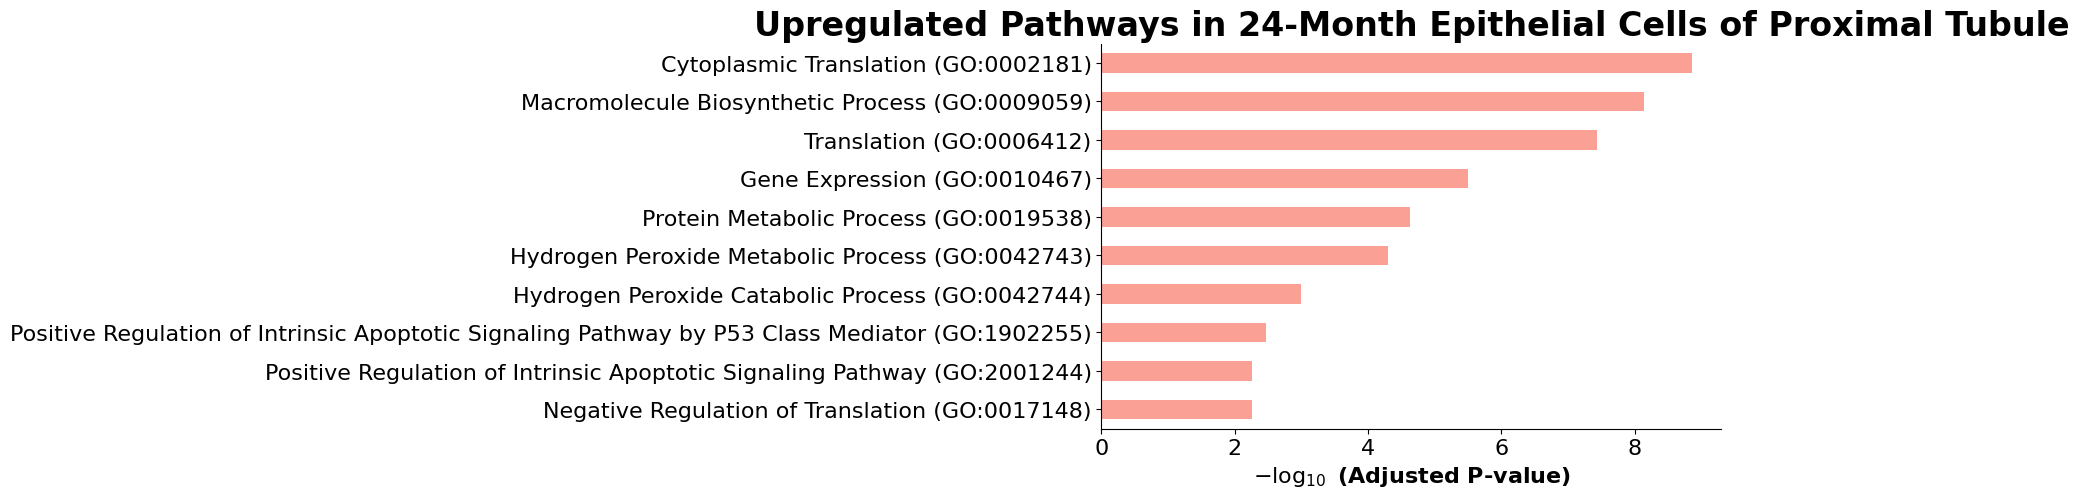

In [7]:
gp.barplot(
    enr.results,
    column="Adjusted P-value",
    title='Upregulated Pathways in 24-Month Epithelial Cells of Proximal Tubule',
    top_term=10,
    figsize=(8, 5)
)
plt.show()